<a href="https://colab.research.google.com/github/vaibhavsingh777/SOC_multimodal_transformer-24b2725/blob/main/task0/task0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1 — Masked mean
Given x of shape (B, T, C) and y of shape (B, T), compute the mean of x across the T dimension, but
only at positions where y == 1. Output shape: (B, C). No Python loops over batch or time. Use
broadcasting and masking.

1. What is a Tensor?
In machine learning, a tensor is simply a container for numbers. You can think of it as a generalization of a matrix that can have any number of dimensions:

0D Tensor: A single number (Scalar)

1D Tensor: A line of numbers (Vector)

2D Tensor: A grid of numbers (Matrix)

3D+ Tensor: A cube (or hypercube) of numbers

If you have used Python's NumPy, a PyTorch tensor is almost identical to a NumPy array. However, PyTorch tensors have two massive superpowers: they can run on GPUs to do math incredibly fast, and they can automatically calculate their own derivatives (gradients) for training neural networks.


In [ ]:
import torch

def masked_mean(x, y):
    """
    Args:
        x: Tensor of shape (B, T, C)
        y: Tensor of shape (B, T) containing 1s and 0s
    Returns:
        Tensor of shape (B, C)
    """
    # Step 1: Expand y's shape from (B, T) to (B, T, 1)
    # This allows it to broadcast across the C dimension of x.
    y_expanded = y.unsqueeze(-1)

    # Step 2: Mask x by multiplying.
    # Positions where y==0 become 0 in x and won't affect the sum.
    masked_x = x * y_expanded

    # Step 3: Sum the masked tensor across the Time dimension (dim=1)
    # The resulting shape is (B, C)
    sum_x = masked_x.sum(dim=1)

    # Step 4: Count how many 1s exist in the Time dimension for each batch
    # keepdim=True makes the shape (B, 1) so it broadcasts over C
    valid_counts = y.sum(dim=1, keepdim=True)

    # Safety feature: Prevent division by zero if a batch has no 1s
    valid_counts = valid_counts.clamp(min=1)

    # Step 5: Divide the sum by the count to get the mean
    # Broadcasting automatically divides (B, C) by (B, 1)
    mean_x = sum_x / valid_counts

    return mean_x

🔎 CURIOSITY CORNER — Beyond Python — what PyTorch actually runs
When you call torch.matmul on a tensor, you are not really executing Python. Underneath, PyTorch
dispatches to highly optimized kernels written in C++ and CUDA. On CPU, it uses libraries like MKL
(Intel) or OpenBLAS. On GPU, it uses cuBLAS and cuDNN. This is why a Python for-loop over tensor
elements is hundreds of times slower than a single matmul — the matmul gets you out of Python
and into a tight C loop.

**Problem 2 — Softmax from scratch**

Implement softmax using only exp, sum, and arithmetic. Verify it matches torch.softmax to 1e-6. Then
explain in writing: why is naive softmax numerically unstable, and what is the standard trick to fix it?


2. What is Softmax?

Softmax is a mathematical function that takes a list of raw, unconstrained numbers (often called "logits") and transforms them into a probability distribution.It does this in two steps:It raises $e$ (Euler's number) to the power of each number, which ensures every value becomes positive and exaggerates the differences between them.It divides each exponentiated value by the sum of all the exponentiated values, ensuring the final list of numbers adds up to exactly 1.0.Mathematically, it looks like this:$$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}} $$

In [ ]:
import torch

def custom_softmax(x, dim=-1):
    # Step 1: Find the maximum value along the specified dimension
    x_max = torch.max(x, dim=dim, keepdim=True)[0]

    # Step 2: Subtract the max for numerical stability (the "trick")
    x_safe = x - x_max

    # Step 3: Exponentiate and sum
    exp_x = torch.exp(x_safe)
    sum_exp_x = torch.sum(exp_x, dim=dim, keepdim=True)

    # Step 4: Divide to get probabilities
    return exp_x / sum_exp_x

# --- Verification ---
# Generate some random logits (e.g., Batch of 4, 10 classes)
logits = torch.randn(4, 10)

# Compute both softmaxes
custom_out = custom_softmax(logits)
torch_out = torch.softmax(logits, dim=-1)

# Verify the maximum difference between the two is less than 1e-6
max_difference = torch.max(torch.abs(custom_out - torch_out)).item()
print(f"Maximum difference: {max_difference}")

assert max_difference < 1e-6, "The implementation does not match to 1e-6!"
print("Verification passed! Custom softmax matches torch.softmax.")

Maximum difference: 2.9802322387695312e-08
Verification passed! Custom softmax matches torch.softmax.


Why is naive softmax numerically unstable?

If your logits include a value like 1000, calculating the exponent of 1000 overflows to infinity, and the whole softmax becomes NaN (Not a Number).  What is the standard trick to fix it?The fix is to subtract the maximum logit before exponentiating:

softmax(x) = softmax(x - max(x)).

This trick does not change the result mathematically because it cancels out in the ratio.  However, it keeps the largest exponent at $e^0 = 1$, which ensures that nothing overflows.  

Problem 3 — Attention scores two ways

Given Q and K of shape (B, T, d), compute the attention scores matrix (B, T, T) two ways: once
with torch.einsum and once with @ (matmul) plus transpose. Verify they are exactly equal.

In [ ]:
import torch

# Define dimensions
B, T, d = 4, 8, 32 # Batch size, Time (sequence length), Dimension

# Create random Query and Key tensors
Q = torch.randn(B, T, d)
K = torch.randn(B, T, d)

# --- Method 1: Using torch.einsum ---
# 'btd' is Query (Batch, Time, dimension)
# 'bsd' is Key (Batch, Source_time, dimension)
# 'bts' is Output (Batch, Time, Source_time)
scores_einsum = torch.einsum('btd,bsd->bts', Q, K)

# --- Method 2: Using @ (matmul) and transpose ---
# We need to multiply (B, T, d) with (B, d, T) to get (B, T, T).
# We transpose the last two dimensions of K to achieve this.
scores_matmul = Q @ K.transpose(-2, -1)

# --- Verification ---
# Check if the two tensors are exactly equal within a small tolerance
are_equal = torch.allclose(scores_einsum, scores_matmul, atol=1e-6)
print(f"Are the two methods mathematically equal? {are_equal}")

# Optional: Print the maximum absolute difference just to be absolutely sure
max_diff = torch.max(torch.abs(scores_einsum - scores_matmul)).item()
print(f"Maximum difference: {max_diff}")

Are the two methods mathematically equal? True
Maximum difference: 0.0


**🔎 CURIOSITY CORNER — Einsum is your friend**

torch.einsum lets you write tensor contractions as readable strings. For attention scores:
einsum('btd,bsd->bts', Q, K). The letters name the axes; repeated letters get summed over. Once
you internalize it, einsum makes high-dimensional tensor manipulations dramatically clearer than
juggling transpose, unsqueeze, and matmul. The same notation works in NumPy and JAX. Highly
recommended detour: Tim Rocktäschel's tutorial "Einsum is all you need".

Why Both Methods Work

Method 1: torch.einsum


torch.einsum allows you to write tensor contractions as readable strings. The string 'btd,bsd->bts' gives specific instructions to PyTorch:  Keep the batch dimension b aligned.Take the dot product over the shared feature dimension d.Output a grid of every query time step t against every key time step s.
Because the letters name the axes, repeated letters get summed over, making high-dimensional tensor manipulations dramatically clearer.

Method 2: @ (Matmul) + Transpose

The @ operator in PyTorch performs batched matrix multiplication. However, you cannot directly multiply a $(B, T, d)$ matrix with another $(B, T, d)$ matrix. By calling K.transpose(-2, -1), you flip the last two dimensions of $K$, turning it into $(B, d, T)$.When PyTorch computes (B, T, d) @ (B, d, T), it automatically processes the batch dimension in parallel and multiplies the inner matrices to produce the expected $(B, T, T)$ attention scores matrix.

Problem 4 — Causal mask

Build a causal mask of shape (T, T) that is 0 on and below the diagonal and -inf above. Apply it (by
addition) to an attention score matrix before softmax. Visualize the resulting post-softmax attention
matrix for T=8 as a heatmap.

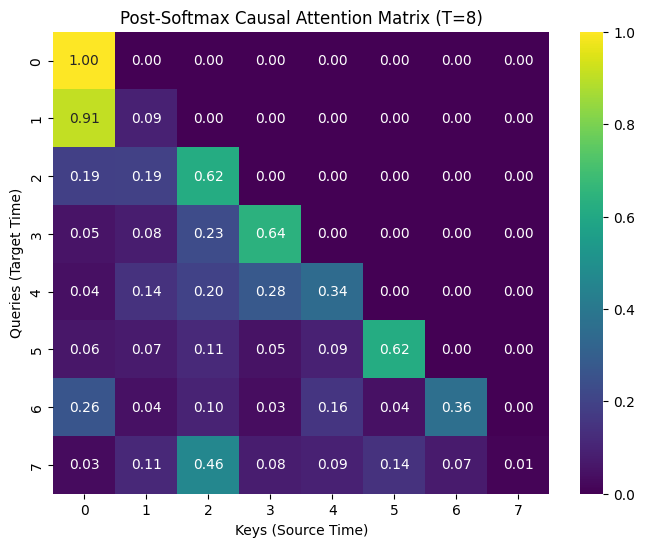

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Set sequence length
T = 8

# 1. Create a simulated attention score matrix (T, T)
# We use random values to simulate the unscaled Q @ K.transpose scores
scores = torch.randn(T, T)

# 2. Build the causal mask
# We create a base tensor of 0s.
mask = torch.zeros(T, T)

# We use torch.tril to get a lower triangular matrix of 1s
tril = torch.tril(torch.ones(T, T))

# We fill the positions where tril is 0 (the upper triangle) with negative infinity
mask = mask.masked_fill(tril == 0, float('-inf'))

# 3. Apply the mask by addition
# Any finite score + (-inf) becomes -inf. The lower triangle remains unchanged (score + 0).
masked_scores = scores + mask

# 4. Apply softmax along the last dimension
# The -inf values get squashed to exactly 0.0 by the softmax operation.
attention_weights = torch.softmax(masked_scores, dim=-1)

# 5. Visualize the resulting matrix as a heatmap
plt.figure(figsize=(8, 6))
# Convert to numpy for visualization
sns.heatmap(attention_weights.numpy(), annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title(f"Post-Softmax Causal Attention Matrix (T={T})")
plt.xlabel("Keys (Source Time)")
plt.ylabel("Queries (Target Time)")
plt.show()

1. What is "Attention"?

Imagine reading the sentence: "The bark of the tree was rough, but the dog's bark was loud."How do you know the first "bark" is wood and the second "bark" is a sound? You know because you look at the surrounding words (context).Before transformers, neural networks processed text sequentially, one word at a time, often forgetting the beginning of a sentence by the time they reached the end. Attention fixes this by allowing the model to look at the entire sequence at once.For every single word in a sentence, the attention mechanism asks: "Which other words in this sentence are most relevant to me right now?"It creates a Query ($Q$) for the current word (What am I looking for?).It checks the Keys ($K$) of all other words (What do you have?).It takes the Values ($V$) of the best matches and squashes them together to create a new, context-rich understanding of that word.

2. What is "Causal" Attention?

Causal attention introduces the "No Time Travel" rule.When a model is training to generate text (like a language model), it has to predict the next word. If you give the model the full sentence during training and let it use standard attention, the word at position 3 could just "look ahead" at position 4 to cheat and find the answer.Causal attention forces the model to play fair. By applying that $-\infty$ mask you just built to the upper triangle of the matrix, you are blinding the model to the future. A word at position $t$ is strictly forced to determine its context using only positions $0$ through $t$. It can only look at the past.

3. Why are we doing all this?

You are doing this because this exact mechanism is the engine of the entire modern AI revolution.It is very easy to just type import transformers and use a high-level wrapper to build a project. But the philosophy of your handbook is clear: the point is not to ship a model fast, but rather to ensure that every line of code you write corresponds to a piece of math you can explain to someone else. If you cannot explain why the code does what it does, the code is not considered finished.  By building self-attention from the ground up without shortcuts, you are taking the "black box" of AI and ripping it open. Once you truly understand how $Q$, $K$, and $V$ interact to form context, every future architecture variant or research paper you read will just look like a slight modification to this very script.

**Problem 5 — LayerNorm from scratch**

Given x of shape (B, T, C), implement LayerNorm: compute the mean and variance over the C
dimension only (per-token, per-batch), normalize, then apply a learnable scale γ and shift β. Match
nn.LayerNorm output to 1e-5.

In [1]:
import torch
import torch.nn as nn

class LayerNormScratch(nn.Module):
    def __init__(self, ndim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # Learnable scale (gamma) and shift (beta)
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim))

    def forward(self, x):
        # x is of shape (B, T, C)

        # 1. Compute the mean along the last dimension (C)
        # keepdim=True ensures the shape becomes (B, T, 1) for broadcasting
        mean = x.mean(dim=-1, keepdim=True)

        # 2. Compute the variance along the last dimension (C)
        # CRITICAL: LayerNorm uses biased variance (unbiased=False)
        var = x.var(dim=-1, unbiased=False, keepdim=True)

        # 3. Normalize
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # 4. Scale and shift
        # weight and bias are shape (C,), they broadcast over (B, T, C)
        out = self.weight * x_norm + self.bias

        return out

# ==========================================
# Verification Test
# ==========================================
if __name__ == "__main__":
    torch.manual_seed(42)

    B, T, C = 2, 8, 16 # Batch, Tokens, Channels
    x = torch.randn(B, T, C)

    # Instantiate both modules
    custom_ln = LayerNormScratch(ndim=C)
    pytorch_ln = nn.LayerNorm(normalized_shape=C)

    # Forward passes
    out_custom = custom_ln(x)
    out_pytorch = pytorch_ln(x)

    # Check max difference
    max_diff = (out_custom - out_pytorch).abs().max().item()
    print(f"Maximum difference: {max_diff:.8f}")

    # Verify it matches within the requested 1e-5 tolerance
    assert torch.allclose(out_custom, out_pytorch, atol=1e-5), "Outputs do not match!"
    print("Success: custom implementation matches nn.LayerNorm!")

Maximum difference: 0.00000048
Success: custom implementation matches nn.LayerNorm!


The core idea of LayerNorm is to take the features of a single token (or sample) and standardize them so they have a mean of zero and a variance of one, before applying a custom scale and shift.

For an input vector $x$ containing $C$ features (representing a single token in a batch), the math flows as follows:

### 1. The Mean (Average)

First, we calculate the average value of all the features for that specific token.


$$\mu = \frac{1}{C} \sum_{i=1}^{C} x_i$$

* **What it does:** Finds the center point of the token's activations.

### 2. The Variance (Spread)

Next, we measure how far the features spread out from that mean. As noted in the PyTorch implementation, LayerNorm uses the **biased** variance, meaning we divide by $C$ rather than $C-1$.


$$\sigma^2 = \frac{1}{C} \sum_{i=1}^{C} (x_i - \mu)^2$$

* **What it does:** Quantifies the average squared distance of each feature from the mean $\mu$.

### 3. The Normalization

We subtract the mean from the input and divide by the standard deviation (the square root of the variance). We also add a tiny constant, $\epsilon$ (epsilon), to the variance before taking the square root.


$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

* **What it does:** Forces the token's features to have a mean of **0** and a variance of **1**.
* **Why $\epsilon$?** It prevents a division-by-zero error in the rare case that the variance is exactly zero (i.e., all features have the exact same value).

### 4. The Affine Transformation (Scale and Shift)

Finally, the normalized values are multiplied by a learned scaling parameter, $\gamma$ (gamma, or "weight"), and added to a learned shifting parameter, $\beta$ (beta, or "bias").


$$y_i = \gamma_i \hat{x}_i + \beta_i$$

* **What it does:** Gives the neural network the flexibility to undo the normalization if doing so is better for learning. While $\mu$ and $\sigma^2$ are computed dynamically on the fly for every single token, $\gamma$ and $\beta$ are learned weights that apply consistently across the whole model.

**🔎 CURIOSITY CORNER — LayerNorm vs BatchNorm vs RMSNorm**

BatchNorm normalizes across the batch dimension and works beautifully for CNNs on images, but
fails for variable-length sequences and small batches. LayerNorm normalizes across the feature
dimension per example, so it doesn't care about batch size — which is why *every transformer uses
it*.

RMSNorm goes further: it drops the mean-centering step and only normalizes by root-mean-square.
It is slightly cheaper and works just as well in practice. *LLaMA and many modern LLMs use
RMSNorm instead of LayerNorm*.

##Problem 6 — Manual gradients
Take x = torch.randn(4, requires_grad=True).

Compute y = (x**2).sum(), call y.backward(),
and manually compute on paper what x.grad should be. Verify. Then repeat for y =
torch.softmax(x, dim=0).sum() and explain why the gradient looks the way it does

(hint: derivative
of softmax has a specific structure).

### Part 1: The Sum of Squares

You are defining a vector $x = [x_1, x_2, x_3, x_4]$ and computing:


$$y = \sum_{i=1}^{4} x_i^2 = x_1^2 + x_2^2 + x_3^2 + x_4^2$$

**Manual Derivation:**
To find `x.grad`, we need the partial derivative of $y$ with respect to each element $x_i$. Because $y$ is a simple sum of independent terms, the derivative of $y$ with respect to $x_i$ only depends on $x_i$:


$$\frac{\partial y}{\partial x_i} = \frac{\partial}{\partial x_i} (x_i^2) = 2x_i$$

Therefore, the gradient vector is simply:


$$\nabla_x y = [2x_1, 2x_2, 2x_3, 2x_4] = 2x$$

**PyTorch Verification:**




In [3]:
import torch

def test_sum_of_squares_gradient():
    print("--- Part A: Sum of Squares Gradient ---")

    # 1. Initialize x
    # We use a specific seed or just random, but let's fix it for reproducible output
    torch.manual_seed(42)
    x = torch.randn(4, requires_grad=True)

    # 2. Compute y = sum(x_i^2)
    y = (x**2).sum()

    # 3. Backpropagate to compute gradients
    y.backward()

    # 4. Manual computation (Analytical gradient)
    # As derived: dy/dx_i = 2 * x_i
    manual_grad = 2 * x.data

    # 5. Output and Verification
    print(f"Original x:      {x.data}")
    print(f"Computed y:      {y.item():.4f}\n")
    print(f"PyTorch x.grad:  {x.grad}")
    print(f"Manual Gradient: {manual_grad}\n")

    # Check if they match exactly (within floating point tolerance)
    match = torch.allclose(x.grad, manual_grad)
    print(f"Do the gradients match? {match}")

if __name__ == "__main__":
    test_sum_of_squares_gradient()

--- Part A: Sum of Squares Gradient ---
Original x:      tensor([0.3367, 0.1288, 0.2345, 0.2303])
Computed y:      0.2380

PyTorch x.grad:  tensor([0.6734, 0.2576, 0.4689, 0.4607])
Manual Gradient: tensor([0.6734, 0.2576, 0.4689, 0.4607])

Do the gradients match? True



### Part 2: The Softmax Sum (The Trick)

Now we compute $y = \text{softmax}(x, \text{dim}=0)\text{.sum()}$.

Before writing any calculus, let's look at what the softmax function actually does. Softmax converts any vector of real numbers into a probability distribution. By definition, **a probability distribution always sums to exactly 1.**

Therefore, no matter what values are in $x$, $y$ will always equal $1$.


$$y = \sum_{i=1}^{4} \text{softmax}(x_i) = 1$$

Since $y$ is a constant, its derivative with respect to any input is **0**. Let's prove why this happens mathematically using the specific structure of the softmax derivative.

**Manual Derivation:**
Let $s_i = \text{softmax}(x_i)$. The derivative of the $i$-th softmax output with respect to the $j$-th input is given by the Jacobian matrix:


$$\frac{\partial s_i}{\partial x_j} = s_i(\delta_{ij} - s_j)$$


*(Note: $\delta_{ij}$ is the Kronecker delta, which is 1 if $i=j$ and 0 if $i \neq j$.)*

We want the gradient of the sum $y = \sum_i s_i$ with respect to a specific input $x_j$:


$$\frac{\partial y}{\partial x_j} = \sum_{i=1}^{4} \frac{\partial s_i}{\partial x_j}$$

Let's substitute the Jacobian formula into our sum:


$$\frac{\partial y}{\partial x_j} = \sum_{i=1}^{4} s_i(\delta_{ij} - s_j)$$

Now, split the sum into two parts: the case where $i = j$, and the cases where $i \neq j$:


$$\frac{\partial y}{\partial x_j} = s_j(1 - s_j) + \sum_{i \neq j} s_i(0 - s_j)$$

$$\frac{\partial y}{\partial x_j} = s_j - s_j^2 - s_j \sum_{i \neq j} s_i$$

Because all probabilities must sum to 1 ($\sum_{i=1}^4 s_i = 1$), the sum of all elements *except* $s_j$ must be $1 - s_j$:


$$\sum_{i \neq j} s_i = 1 - s_j$$

Substitute this back in:


$$\frac{\partial y}{\partial x_j} = s_j - s_j^2 - s_j(1 - s_j)$$

$$\frac{\partial y}{\partial x_j} = s_j - s_j^2 - s_j + s_j^2 = 0$$

Every term cancels out perfectly. The gradient is exactly zero everywhere.

**PyTorch Verification:**


In [4]:
import torch

def test_softmax_sum_gradient():
    print("--- Part B: Softmax Sum Gradient ---")

    # 1. Initialize x
    torch.manual_seed(42)
    x = torch.randn(4, requires_grad=True)

    # 2. Compute y = sum(softmax(x))
    # Softmax over dimension 0 converts the vector into probabilities
    y = torch.softmax(x, dim=0).sum()

    # 3. Backpropagate to compute gradients
    y.backward()

    # 4. Manual computation (Analytical gradient)
    # As derived: dy/dx_i = 0 because y is always exactly 1.0
    manual_grad = torch.zeros_like(x.data)

    # 5. Output and Verification
    print(f"Original x:      {x.data}")
    # y should be exactly 1.0 (or 0.9999999 due to floating point math)
    print(f"Computed y:      {y.item():.8f}\n")

    print(f"PyTorch x.grad:  {x.grad}")
    print(f"Manual Gradient: {manual_grad}\n")

    # Check if they match exactly (within floating point tolerance)
    match = torch.allclose(x.grad, manual_grad)
    print(f"Do the gradients match? {match}")

if __name__ == "__main__":
    test_softmax_sum_gradient()

--- Part B: Softmax Sum Gradient ---
Original x:      tensor([0.3367, 0.1288, 0.2345, 0.2303])
Computed y:      1.00000000

PyTorch x.grad:  tensor([0., 0., 0., 0.])
Manual Gradient: tensor([0., 0., 0., 0.])

Do the gradients match? True


##🔎 CURIOSITY CORNER — Autograd is not magic
PyTorch's autograd builds a directed graph of operations as you run forward, then traverses it in
reverse to apply the chain rule. Every operation knows how to compute its local gradient. When you
write a custom layer, the autograd system handles backprop for you as long as you only use
differentiable ops. If you ever need a custom backward — for non-differentiable steps like sampling,
or for a more efficient gradient than the default — you subclass torch.autograd.Function. You will
not need this in the project, but knowing it exists is useful.